# Experiment 2: Metadata

In this experiment, we will try 3 retrieval strategies that differ in how metadata is incorporated into the document representation: 
- **Baseline**: document chunks are embedded using only their textual content, without metadata. 
- **Concat**: document-level metadata is concatenated with each text chunk prior to embedding, allowing metadata and content to be represented in a single embedding space.
- **Dual**: text and document-level metadata are embedded separately, and their similarities with query are combined at retrieval time using a weighted scoring function. 


As in 1st experiment we concluded that LLM chunking is better, we will use LLM chunking for this experiment. 

## PART 1: create metadata with LLM and save in .json

In [1]:
import os
import json
import time
import requests
from pathlib import Path
import fitz #pip install PyMuPDF

  
from embedder import Embedder

C:\Users\lucia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path("data")
PDF_DIR = Path("pdfs")

DATA_DIR.mkdir(exist_ok=True)

META_CACHE_PATH = DATA_DIR / "llm_metadata_cache.json"

api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    raise RuntimeError("Missing GEMINI_API_KEY environment variable")

if META_CACHE_PATH.exists():
    with META_CACHE_PATH.open("r", encoding="utf-8") as f:
        metadata_cache = json.load(f)
else:
    metadata_cache = {}

In [3]:
def extract_text_from_pdf(pdf_path: Path) -> str:
    doc = fitz.open(pdf_path)
    text = "".join(page.get_text() for page in doc)
    doc.close()
    return text


def extract_llm_metadata(doc_text: str) -> dict:
    """
    Calls Gemini and returns structured metadata as JSON
    """

    snippet = doc_text[:12000]  # no cal enviar-ho tot

    prompt = f"""
        You are extracting bibliographic and topical metadata from a PDF text dump.
        Return ONLY valid JSON (no markdown).

        Schema:
        {{
        "title": string|null,
        "authors": [string],
        "year": int|null,
        "keywords": [string],
        "topics": [string],
        "one_sentence_summary": string|null
        }}

        Rules:
        - If unsure, use null or empty lists
        - Do not hallucinate author names
        - Base everything strictly on the provided text

        TEXT:
        {snippet}
        """.strip()

    url = (
        "https://generativelanguage.googleapis.com/v1beta/"
        "models/gemini-2.5-flash:generateContent"
    )

    headers = {
        "Content-Type": "application/json",
        "x-goog-api-key": api_key
    }

    payload = {
        "contents": [
            {"parts": [{"text": prompt}]}
        ]
    }

    response = requests.post(url, headers=headers, json=payload)
    response.raise_for_status()

    data = response.json()
    raw = data["candidates"][0]["content"]["parts"][0]["text"]

    raw = raw.strip().replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(raw)
    except json.JSONDecodeError as e:
        print("\n=== JSON PARSE FAILED ===")
        print("Error:", e)
        print("RAW OUTPUT:\n", raw)
        print("========================\n")
        raise


def build_metadata_cache(pdf_paths):
    for pdf_path in pdf_paths:
        pdf_name = pdf_path.name

        if pdf_name in metadata_cache:
            print(f"Cached: {pdf_name}")
            continue

        print(f"Processing: {pdf_name}")

        text = extract_text_from_pdf(pdf_path)
        metadata = extract_llm_metadata(text)

        metadata_cache[pdf_name] = metadata

        META_CACHE_PATH.write_text(
            json.dumps(metadata_cache, indent=2, ensure_ascii=False),
            encoding="utf-8"
        )

        time.sleep(4)  # rate limiting

In [4]:
pdf_paths = list(PDF_DIR.glob("*.pdf"))

build_metadata_cache(pdf_paths)

print("Metadata cache created:", META_CACHE_PATH)

Metadata cache created: data\llm_metadata_cache.json


## PART 2: read llm_metadata_cache.json and create embeddings

In [5]:
BASE_DIR = Path.cwd().parents[0]   # backend/
PDF_EXAMPLES = BASE_DIR/ "example_pdfs_to_upload"

DATA_DIR = BASE_DIR / "data"
META_CACHE_PATH = DATA_DIR / "llm_metadata_cache.json"
LLM_CHUNKS_PATH = BASE_DIR / "llm_database.json" #ATATA CAMBIAR A DATA??

if not META_CACHE_PATH.exists():
    raise RuntimeError("llm_metadata_cache.json not found. Metadata must be precomputed.")

with META_CACHE_PATH.open("r", encoding="utf-8") as f:
    metadata_cache = json.load(f)

In [6]:
def build_metadata_string(llm_meta):

    if not llm_meta:
        return ""
    parts = []
    if llm_meta.get("title"):
        parts.append(f"Title: {llm_meta['title']}")
    if llm_meta.get("topics"):
        parts.append("Topics: " + ", ".join(llm_meta["topics"]))
    if llm_meta.get("keywords"):
        parts.append("Keywords: " + ", ".join(llm_meta["keywords"]))
    if llm_meta.get("one_sentence_summary"):
        parts.append("Summary: " + llm_meta["one_sentence_summary"])
    return "[METADATA]\n" + "\n".join(parts)

def get_llm_metadata(pdf_name: str) -> dict:
    """
    Read-only metadata accessor.
    No LLM calls. No side effects.
    """
    return metadata_cache.get(pdf_name, {})

In [18]:


class DataManager:
    """
    Handles:
    - PDF text extraction
    - Chunking
    - Embedding (baseline / concat / dual)
    """

    def __init__(self, pdf_folder, metadata_mode="concat", llm_db_path = LLM_CHUNKS_PATH):
        self.embedder = Embedder()
        self.pdf_folder = pdf_folder
        self.metadata_mode = metadata_mode
        self.tokenizer = self.embedder.model.tokenizer
        
        with open(llm_db_path, "r", encoding="utf-8") as f:
            llm_db = json.load(f)  

        self.llm_chunks_map = {
            d["pdf_name"]: d.get("chunks", [])  
            for d in llm_db
            if "pdf_name" in d
}
    
    # ------------------------------
    # PDF TEXT EXTRACTION
    # ------------------------------
    def extract_text(self, pdf_path):
        doc = fitz.open(pdf_path)
        text = "".join(page.get_text() for page in doc)
        doc.close()
        return text

    # ------------------------------
    # CHUNKING
    # ------------------------------
    def chunk_text(self, text, chunk_size=400, chunk_overlap=50):
        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        chunks = []
        step = chunk_size - chunk_overlap

        for i in range(0, len(tokens), step):
            chunk_ids = tokens[i:i + chunk_size]
            chunk_text = self.tokenizer.decode(chunk_ids, skip_special_tokens=True)
            chunks.append(chunk_text)

        return chunks
    
    def get_llm_chunks(self, pdf_name):
        chunks = self.llm_chunks_map.get(pdf_name, [])
        if not chunks:
            raise ValueError(f"No LLM chunks found for {pdf_name} in llm_database.json")
        return chunks

    # ------------------------------
    # MAIN PIPELINE
    # ------------------------------
    def process_pdf(self, pdf_path, mode="baseline"):
        text = self.extract_text(pdf_path)
        #chunks = self.chunk_text(text)
        chunks_from_json = self.get_llm_chunks(pdf_path.name)
        chunks = [c['text'] for c in chunks_from_json]

        llm_meta = {}
        meta_str = ""

        if mode in ("concat", "dual", "meta_only"):
            llm_meta = get_llm_metadata(pdf_path.name)
            meta_str = build_metadata_string(llm_meta)

        if mode == "dual":
            emb_meta = self.embedder.encode(meta_str)

        if mode == "meta_only":
            emb_meta = self.embedder.encode(meta_str)
            chunk_records = [{
                "text": meta_str, 
                "embedding": emb_meta
            }]
            return {"pdf_name": pdf_path.name, "llm_metadata": llm_meta, "chunks": chunk_records}
        
        chunk_records = []

        for chunk in chunks:
            if mode == "baseline":
                emb = self.embedder.encode(chunk)
                chunk_records.append({
                    "text": chunk,
                    "embedding": emb
                })

            elif mode == "concat":
                emb = self.embedder.encode(chunk + "\n\n" + meta_str)
                chunk_records.append({
                    "text": chunk,
                    "embedding": emb
                })

            elif mode == "dual":
                emb_text = self.embedder.encode(chunk)
                chunk_records.append({
                    "text": chunk,
                    "embedding_text": emb_text,
                    "embedding_meta": emb_meta
                })

        return {
            "pdf_name": pdf_path.name,
            "llm_metadata": llm_meta,
            "chunks": chunk_records}

    # ------------------------------
    # INDEX BUILDING
    # ------------------------------
    def build_index(self, pdf_paths, mode="baseline"):
        database = []

        for pdf_path in pdf_paths:
            entry = self.process_pdf(pdf_path, mode=mode)
            print(f"Indexed: {pdf_path.name}")
            database.append(entry)

        return database


In [8]:
import numpy as np

class BaselineRetriever:
    def __init__(self, database=None, embedder=None, mode="not_dual"):
        self.embedder = embedder or Embedder()
        self.database = database or []
        self.mode = mode  # "not_dual" or "dual"

    def cosine_similarity(self, v1, v2):
        v1 = np.array(v1)
        v2 = np.array(v2)
        return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

    def search(self, query, threshold=0.70, alpha=0.7):
        query_emb = self.embedder.encode(query)
        results = []

        for entry in self.database:
            best_score = 0.0
            best_chunk = None

            for chunk in entry.get("chunks", []):
                if self.mode == "dual":
                    s_text = self.cosine_similarity(query_emb, chunk["embedding_text"])
                    s_meta = self.cosine_similarity(query_emb, chunk["embedding_meta"])
                    score = alpha * s_text + (1 - alpha) * s_meta
                else:
                    score = self.cosine_similarity(query_emb, chunk["embedding"])

                if score > best_score:
                    best_score = score
                    best_chunk = chunk

            if best_score >= threshold:
                results.append({
                    "paper_id": entry.get("pdf_name", ""),
                    "title": entry.get("llm_metadata", {}).get("title", entry.get("pdf_name", "")),
                    "pdf_name": entry.get("pdf_name", ""),
                    "score": round(best_score, 3),
                    "sample_text": best_chunk["text"][:300] if best_chunk else ""
                })

        results.sort(key=lambda x: x["score"], reverse=True)
        return results


In [19]:
embedder = Embedder()
dm = DataManager(pdf_folder=PDF_EXAMPLES)

pdf_paths = list(PDF_EXAMPLES.glob("*.pdf"))

baseline_db = dm.build_index(pdf_paths, mode="baseline")
baseline_retriever = BaselineRetriever(baseline_db, embedder)

Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

In [20]:
concat_db   = dm.build_index(pdf_paths, mode="concat")
concat_retriever   = BaselineRetriever(concat_db, embedder)

Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

In [21]:
dual_db     = dm.build_index(pdf_paths, mode="dual")
dual_retriever     = BaselineRetriever(dual_db, embedder, mode="dual")

Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

In [22]:
meta_only_db     = dm.build_index(pdf_paths, mode="meta_only")
meta_only_retriever     = BaselineRetriever(meta_only_db, embedder)

Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

## PART 3: run evaluation

We define different sets of evaluation pairs, with queries and the most relevant document they should retrieve.


In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

In [24]:
queries_easy = {
    "GDPR compliance and neuroimaging data privacy": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "bottleneck fusion for multimodal medical data integration": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory clinical metrics for alzheimers disease classification": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "tau protein biomarkers and hippocampal atrophy correlation": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "hyperparameter sweep and weights and biases tracking": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "docker environment setup for local hardware clusters": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "synthetic data generation and smote for class imbalance": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "weekly team sync and tau protein data audit": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "scaled dot product attention mechanism": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "deep residual learning for image recognition": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "vision transformer using image patches": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "retrieval augmented generation for nlp tasks": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adam optimizer for stochastic optimization": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "taxonomy of multimodal machine learning": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "pathological network model for alzheimers interventions": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "graph model of tau pathology spreading": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "personalized trajectories of cortical atrophy": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "pathology steered stratification for subtype identification": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "video reasoning over traffic events benchmark": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "deep counterfactuals for alzheimers prediction": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "multimodal attention for disease diagnosis": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "evaluating disease focus in deep learning models": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "explainable ai requirements for clinicians": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "transfer learning for 3d medical image analysis": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "generative adversarial networks in medical imaging review": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "success factors for scientific teams": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "monetary value of large scientific collaboration": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher perceptions of llm tools": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [25]:
queries_intermediate = {
    "distinction between pseudonymization and anonymization under gdpr": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "kl divergence for latent space regularization": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "area under the precision recall curve for imbalanced data": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "k-nearest neighbors imputation for missing tau protein values": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "optimal batch size and learning rate interaction in adamw": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "solving numpy and scipy version mismatch for linear algebra": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "elastic transformations for simulating anatomical variability": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "dynamic masking for incomplete multimodal inputs": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "multi-head self-attention and position-wise feed-forward networks": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "shortcut connections and identity mapping for optimization": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "transformer encoder blocks for fine-grained image recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "knowledge-intensive tasks using dense vector retrieval": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adaptive moment estimation mechanics for deep learning": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "challenges in cross-modal alignment and feature fusion": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "combinatorial intervention strategies for alzheimers networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot inverse solver for two-species graph models": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "spatiotemporal modeling of cortical atrophy trajectories": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "subtype identification in alzheimers using stratification networks": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "efficient networks for temporal reasoning in video": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "interpretable volumetric changes using deep counterfactuals": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "attention weights for integrating imaging and clinical data": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "quantitative metrics for disease focus and saliency maps": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinical requirements for explainable ai decision support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical imaging analysis using pre-trained med3d models": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "gan applications for medical image synthesis and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "link between scientific team freshness and success": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "productivity estimates of large scale scientific collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "large scale survey of researcher usage of llms": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [26]:
queries_difficult = {
    "unauthorized data transfer to neurocloud analytic solutions": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "intermediate fusion vs early fusion for 3d mri data": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory external validation using oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "missing tau protein data for subjects ad-102 to ad-118": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "mri encoder overfitting patterns starting at epoch 50": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "cuda 12.1 and pytorch 2.4.0 cluster requirements": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "parameters for bob's elastic transform alpha 50 and sigma 8": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "audit of pet-tau tracers for 24-month follow-up window": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "square root of dk scaling factor in attention": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "convergence of stochastic gradient descent in deep residuals": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "16x16 pixel image patch size for transformer recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "parametric generator and non-parametric retriever synergy": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "bias correction using first and second moment estimates": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "co-learning and modality representation mismatch": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "dynamic interventions in pathological protein networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot solver for graph models of neurodegeneration": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "longitudinal modeling of atrophy in alzheimers patient cohorts": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "stratification network performance across diverse alzheimers subtypes": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "temporal reasoning benchmarks for traffic event qa": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "quantitative interpretation of brain region volumetric changes": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "integrated analysis of pet scans and clinical cognitive scores": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "saliency map evaluation and disease relevant features": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinician centered explainable ai for critical care support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical analysis using transfer learning on large scale datasets": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "adversarial training for medical image segmentation and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "scientific team success through fresh perspectives": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "economic analysis of scientific productivity in large collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher tool usage and perceptions survey results": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [27]:
queries_multi_documents = {
    "tau protein data missingness and audit results": [
        "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "implementation and technical parameters of elastic deformation": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf"
    ],
    "data processing agreement and prohibition of cloud services": [
        "2026-01-05_Alice-Robertson_Compliance-Review.pdf", 
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf"
    ],
    "mandatory metrics and the transition away from simple accuracy": [
        "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf", 
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf"
    ],
    "transformer based bottleneck fusion architecture and cross attention layers": [
        "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf", 
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "integration and standardization of the oasis-3 dataset": [
        "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "dockerized environment and training on the local h100 cluster": [
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "overfitting in mri encoder branch and its clinical regularization": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "augmentation strategies including smote and 3d mri transformations": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf"
    ],
    "gdpr compliance and the distinction between pseudonymization and anonymization": [
        "2026-01-05_Alice-Robertson_Compliance-Review.pdf", 
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf"
    ]
}

In [28]:
queries_traps = {
    # 1. THE ATTRIBUTION TRAP (Bob vs. Daniel)
    # Testing if the system can distinguish the source of a discovery from a summary.
    "primary discovery of tau-protein missingness in the proteomics dataset": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",

    # 2. THE CHRONOLOGICAL/VERSION TRAP (Chloe Jan 16 vs. Bob Jan 22)
    # Chloe says alpha=8, Bob says alpha=50. A researcher wants the implementation log.
    "implementation parameters for bob martinez elastic transformations alpha and sigma": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",

    # 3. THE ADMINISTRATIVE PRIORITY TRAP (Compliance vs. Setup)
    # Testing if the system prioritizes the "Why/Rule" over the "How/Code".
    "formal institution policy on pseudonymization versus anonymization": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",

    # 4. THE MODALITY OVERFITTING TRAP (Architecture vs. Results)
    # Chloe proposes fusion in one doc, but documents the branch failure in another.
    "empirical evidence of overfitting in the mri-only encoder branch": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",

    # 5. THE EXTERNAL VALIDATION TRAP (Protocol vs. Meeting)
    # Alice mandates the dataset; Daniel just prepares a template for it.
    "formal mandate for model evaluation on the oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",

    # 6. THE NUMERICAL INSTABILITY TRAP (Environment vs. Sweep)
    # Testing if "instability" leads to Hyperparameters (Common) or the specific NumPy fix.
    "resolution of floating-point overflows and nan values in mri preprocessing": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",

    # 7. THE "SALIENCY" ASSIGNMENT TRAP (Task List vs. Tech Proposal)
    # Testing if the system can find the assigned "Action Item" owner.
    "assignment of explainable ai xai saliency map generation": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
}

We use as metrics:
- Mean Reciprocal Rank (MRR)
- Hit_rate@3
- Mean Average Precision (MAP)

In [29]:
def reciprocal_rank(ranked_docs, relevant_docs):
    """
    Reciprocal Rank (RR)
    relevant_docs can be a single item or a set
    """
    if isinstance(relevant_docs, str):
        relevant_docs = {relevant_docs}

    for i, doc in enumerate(ranked_docs, start=1):
        if doc in relevant_docs:
            return 1.0 / i
    return 0.0


def hit_at_k(ranked_docs, relevant_docs, k=3):
    """
    Hit@K
    relevant_docs can be a single doc or a set/list
    """
    if isinstance(relevant_docs, str):
        relevant_docs = {relevant_docs}
    else:
        relevant_docs = set(relevant_docs)

    return int(any(doc in relevant_docs for doc in ranked_docs[:k]))


def average_precision(ranked_docs, relevant_docs):
    """
    Average Precision (AP) for multi-doc relevance
    """
    relevant_docs = set(relevant_docs)
    hits = 0
    precisions = []

    for i, doc in enumerate(ranked_docs, start=1):
        if doc in relevant_docs:
            hits += 1
            precisions.append(hits / i)

    return np.mean(precisions) if precisions else 0.0

In [30]:
def ranked_docs_from_retriever(retriever, query, alpha=0.5, max_k=None):
    """
    Runs retrieval and returns a ranked list of pdf_names
    """
    results = retriever.search(query, threshold=0.0, alpha=alpha)
    if max_k:
        results = results[:max_k]
    return [r["pdf_name"] for r in results]

In [31]:
def evaluate_queries(retriever, queries, metric_fn, alpha=0.5, max_k=None, k=None):

    scores = []
    for query, targets in queries.items():
        ranked_docs = ranked_docs_from_retriever(retriever, query, alpha=alpha, max_k=max_k)
        if k is not None:
            scores.append(metric_fn(ranked_docs, targets, k=k))
        else:
            scores.append(metric_fn(ranked_docs, targets))

    return float(np.mean(scores))

#### 3.1 Optimize Dual alpha

- Evaluation queries: difficult queries and traps
- Metrics: MRR

In [32]:
def optimize_alpha(retriever, query_sets, metric_fn, alpha_range=None):
    """
    query_sets: dict[name -> queries]
    """
    if alpha_range is None:
        alpha_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

    rows = []
    for alpha in alpha_range:
        print("Compute alpha", alpha)
        row = {"alpha": alpha}
        for name, queries in query_sets.items():
            row[name] = evaluate_queries(retriever, queries, metric_fn, alpha=alpha)
        rows.append(row)

    return pd.DataFrame(rows)

In [33]:
df_alpha = optimize_alpha(
    dual_retriever,{
        "easy": queries_easy,
        "intermediate": queries_intermediate,
        "difficult": queries_difficult,
        "traps": queries_traps},
    metric_fn=reciprocal_rank)

df_alpha["combined"] = df_alpha[["easy", "intermediate", "difficult", "traps"]].mean(axis=1)
best_alpha = df_alpha.loc[df_alpha["combined"].idxmax(), "alpha"]


Compute alpha 0
Compute alpha 0.1
Compute alpha 0.2
Compute alpha 0.3
Compute alpha 0.4
Compute alpha 0.5
Compute alpha 0.6
Compute alpha 0.7
Compute alpha 0.8
Compute alpha 0.9
Compute alpha 1


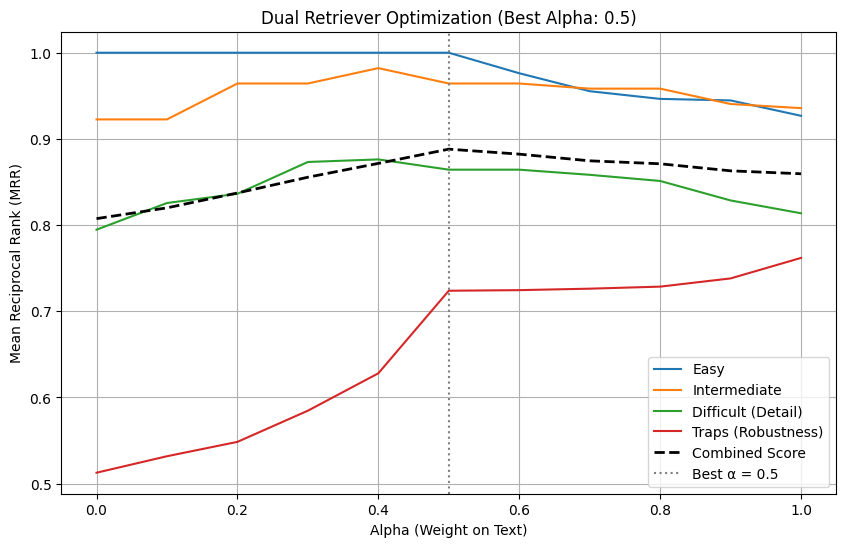

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(df_alpha["alpha"], df_alpha["easy"], label="Easy")
plt.plot(df_alpha["alpha"], df_alpha["intermediate"], label="Intermediate")
plt.plot(df_alpha["alpha"], df_alpha["difficult"], label="Difficult (Detail)")
plt.plot(df_alpha["alpha"], df_alpha["traps"], label="Traps (Robustness)")
plt.plot(df_alpha["alpha"],df_alpha["combined"],label="Combined Score",linestyle="--",linewidth=2,color="black")

plt.axvline(best_alpha, linestyle=":", color="gray", label=f"Best α = {best_alpha}")

plt.title(f"Dual Retriever Optimization (Best Alpha: {best_alpha})")
plt.xlabel("Alpha (Weight on Text)")
plt.ylabel("Mean Reciprocal Rank (MRR)")
plt.legend()
plt.grid(True)
plt.show()


#### 3.2 Comparing retrieval methods

- Evaluation queries: easy, intermediate, difficult and multi-document queries
- Metrics: MAP, MRR and Hit@3

In [35]:
def run_full_evaluation(retrievers, alpha_dual=0.5):
    rows = []

    for name, retriever in retrievers.items():
        alpha = alpha_dual if name == "Dual" else 0.5

        row = {
            "Method": name,
            # Easy
            "Easy Hit@3": evaluate_queries(retriever, queries_easy, hit_at_k, alpha=alpha, k=3),
            "Easy MRR": evaluate_queries(retriever, queries_easy, reciprocal_rank, alpha=alpha),
            # Intermediate
            "Int Hit@3": evaluate_queries(retriever, queries_intermediate, hit_at_k, alpha=alpha, k=3),
            "Int MRR": evaluate_queries(retriever, queries_intermediate, reciprocal_rank, alpha=alpha),
            # Difficult
            "Diff Hit@3": evaluate_queries(retriever, queries_difficult, hit_at_k, alpha=alpha, k=3),
            "Diff MRR": evaluate_queries(retriever, queries_difficult, reciprocal_rank, alpha=alpha),
            # Multi-doc semantic synthesis
            "Multi-doc MAP": evaluate_queries(retriever, queries_multi_documents, average_precision, alpha=alpha)
        }
        rows.append(row)

    return pd.DataFrame(rows).round(3)


retrievers = {
    "Baseline": baseline_retriever,
    "Concat": concat_retriever,
    "Dual": dual_retriever,
    "Meta-only": meta_only_retriever}

final_results = run_full_evaluation(retrievers, alpha_dual=0.5)

print("\n=== FINAL RETRIEVAL METHOD COMPARISON ===")
print(final_results.to_string(index=False))


=== FINAL RETRIEVAL METHOD COMPARISON ===
   Method  Easy Hit@3  Easy MRR  Int Hit@3  Int MRR  Diff Hit@3  Diff MRR  Multi-doc MAP
 Baseline       0.929     0.927      0.964    0.936       0.893     0.814          0.744
   Concat       0.964     0.954      0.964    0.952       0.929     0.885          0.713
     Dual       1.000     1.000      1.000    0.964       0.964     0.864          0.777
Meta-only       1.000     1.000      0.964    0.923       0.857     0.795          0.670


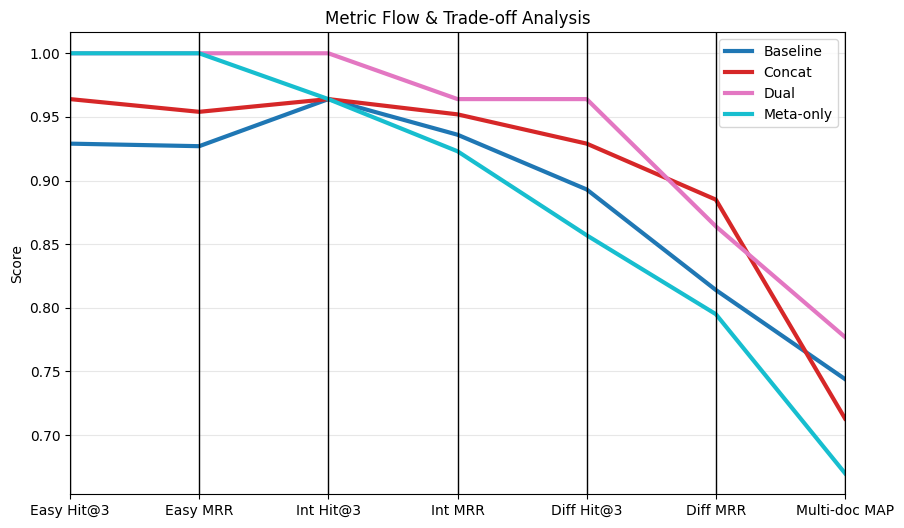

In [36]:
def plot_parallel_matplotlib(df):
    metrics = [col for col in df.columns if "MRR" in col or "Hit@3" in col or "MAP" in col]
    plot_df = df[['Method'] + metrics]

    plt.figure(figsize=(10, 6))
    parallel_coordinates(plot_df, 'Method', colormap='tab10', axvlines=True, linewidth=3)
    
    plt.title("Metric Flow & Trade-off Analysis")
    plt.ylabel("Score")
    plt.grid(alpha=0.3)
    plt.show()

plot_parallel_matplotlib(final_results)

- **Baseline**: remains relatively stable across complexity levels, but it consistently underperforms compared to metadata-aware methods. While it achieves reasonable scores on easy and intermediate queries, its lack of explicit semantic and contextual signals results in weaker ranking for difficult queries and multi-document retrieval scenarios.

- **Concatenate**: The concatenate approach improves over the baseline in most settings, particularly for difficult queries, indicating that injecting metadata directly into the chunk text helps guide retrieval. However, this improvement comes at the cost of slightly worse multi-document MAP, suggesting that simple concatenation may introduce noise that affects global document ranking.

- **Metadata-only**: This method performs exceptionally well for easy queries (1.000 Hit@3 and MRR), confirming that high-level document attributes are sufficient when the query intent is broad. However, performance drops noticeably as query complexity increases, achieving the lowest MRR for difficult queries and the weakest multi-document MAP. This highlights a semantic collapse effect: metadata alone fails when relevant information is embedded in specific technical sections of the text.

- **Dual**: The dual approach consistently achieves the best overall performance. It reaches perfect scores for easy and intermediate Hit@3, maintains the highest MRR for intermediate queries, and achieves the best multi-document MAP (0.777). This indicates that separating text and metadata embeddings provides a robust balance between high-level context and fine-grained technical detail, especially when combined with semantically coherent LLM-based chunking.

In [37]:
def run_retrievals_once(retrievers, queries, max_k=10):
    """
    Runs retrieval ONCE and stores ranked document lists.
    """
    alpha_by_retriever = {"Dual": best_alpha}
    retrieval_cache = {}
    for name, retriever in retrievers.items():
        alpha = alpha_by_retriever.get(name, 0.5) if alpha_by_retriever else 0.5
        retrieval_cache[name] = {}

        for query in queries:
            ranked_docs = ranked_docs_from_retriever(retriever, query, alpha=alpha, max_k=max_k)
            retrieval_cache[name][query] = ranked_docs

    return retrieval_cache


def visualize_trap_results(retrieval_cache, trap_queries, max_k=10):
    """
    Heatmap of trap-query ranks.
    """
    rows = []

    for retriever_name, queries in retrieval_cache.items():
        for query, target_doc in trap_queries.items():
            ranked_docs = queries.get(query, [])

            rank = None
            for i, doc in enumerate(ranked_docs, start=1):
                if doc == target_doc:
                    rank = i
                    break

            rows.append({"Retriever": retriever_name,"Trap Query": query[:45] + "...","Rank": rank})

    df = pd.DataFrame(rows)
    pivot_values = df.pivot(index="Trap Query", columns="Retriever", values="Rank")
    pivot_labels = pivot_values.applymap(lambda x: "Not Found" if pd.isna(x) else str(int(x)))
    plot_data = pivot_values.fillna(max_k + 1)

    plt.figure(figsize=(12, 8))
    sns.heatmap(plot_data, annot=pivot_labels, fmt="", cmap="RdYlGn_r", vmin=1, vmax=max_k, cbar_kws={"label": "Rank (1 = best)"})
    plt.title("Adversarial Trap Analysis: Attribution & Robustness")
    plt.tight_layout()
    plt.show()


C:\Users\lucia\AppData\Local\Temp\ipykernel_9576\2810877986.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_labels = pivot_values.applymap(lambda x: "Not Found" if pd.isna(x) else str(int(x)))


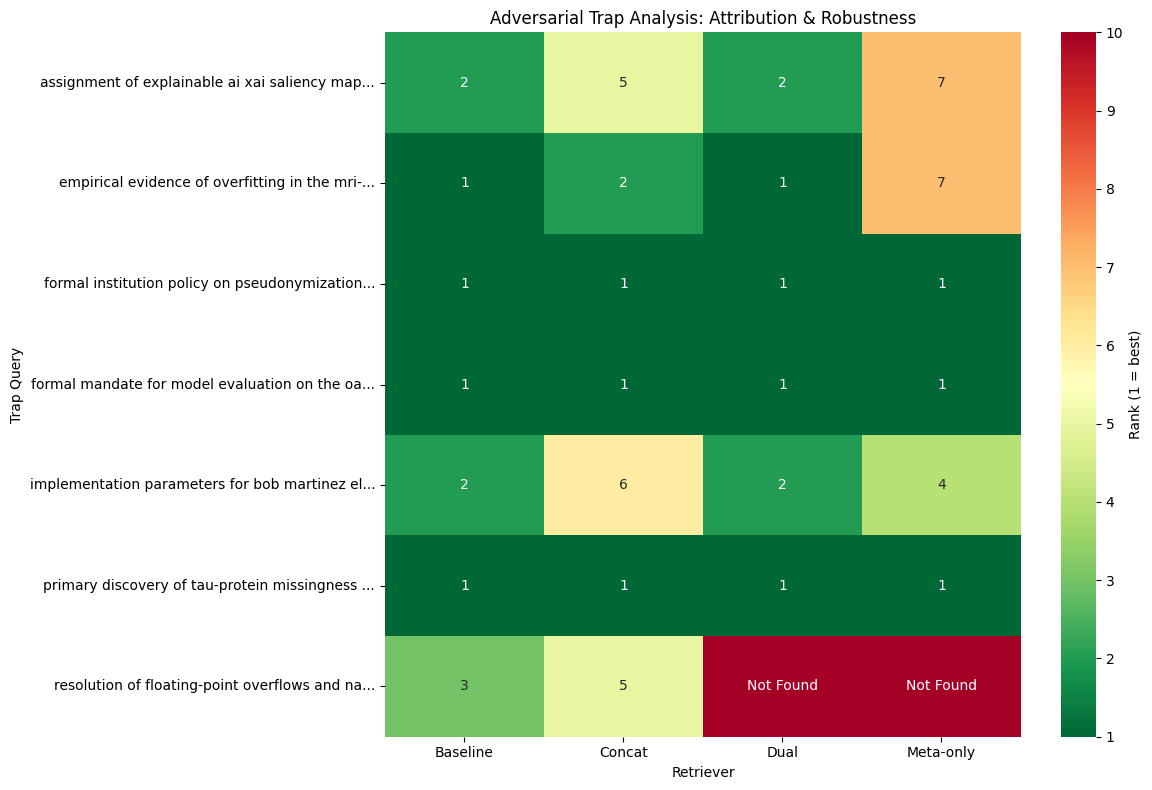

In [38]:
retrieval_traps = run_retrievals_once(
    retrievers,
    queries_traps)

visualize_trap_results(retrieval_traps, queries_traps)

With LLM-based chunking fixed, the baseline text-only retriever becomes highly robust and successfully resolves all adversarial traps. The semantically coherent chunks already capture sufficient contextual information, allowing the baseline to handle both administrative and highly technical queries without relying on metadata. This makes it the most reliable approach in this adversarial setting, particularly for resolution-oriented technical queries.

The concatenate approach shows mixed behavior. While it benefits from metadata and successfully resolves all tasks, its rankings are generally less stable than the baseline and dual approaches. Injecting metadata directly into the text can help in some cases, but it may also introduce noise that affects attribution-sensitive queries.

Metadata-only is the weakest performer under adversarial conditions. Although it works well for broad administrative or high-level queries, it fails on technically grounded traps where the relevant information is embedded deep within the document text. This confirms that metadata alone is insufficient for resolving detailed or resolution-focused queries.

The dual approach performs strongly across most adversarial traps and provides robust rankings for attribution and policy-related queries. However, it fails on the numerical instability trap, suggesting that separating metadata and text embeddings can sometimes dilute highly specific technical signals. While dual retrieval offers a good balance in general, it is not consistently superior when strong semantic chunking is already in place.

Overall, this experiment shows that when LLM-based chunking is fixed, high-quality semantic segmentation already captures most of the necessary context for robust retrieval. In this setting, metadata integration does not always provide a clear advantage and can even introduce noise for highly technical resolution queries. Metadata remains useful for administrative and attribution-focused queries, but strong chunking alone is often sufficient for reliable retrieval.

## OTHER

In [14]:
def hit_at_k_vs_threshold(retrieval_cache, evaluation_pairs, thresholds, k=3):
    hits_by_retriever = {}

    for name, results_by_query in retrieval_cache.items():
        hits_by_retriever[name] = []

        for t in thresholds:
            hits = 0
            for query, expected_pdf in evaluation_pairs.items():
                results = [
                    r for r in results_by_query[query]
                    if r["score"] >= t
                ]

                for r in results[:k]:
                    if r["pdf_name"] == expected_pdf:
                        hits += 1
                        break

            hits_by_retriever[name].append(hits)

    return hits_by_retriever


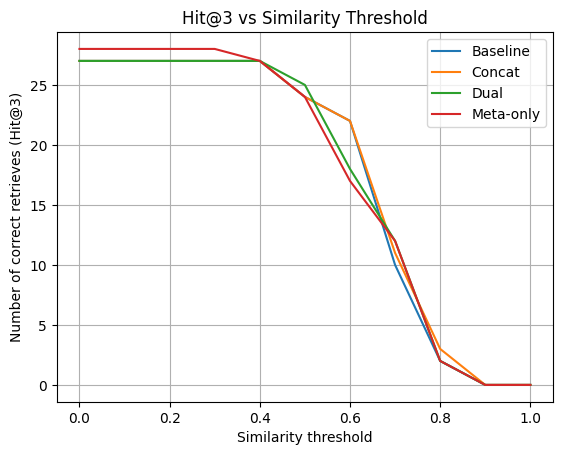

In [15]:
thresholds = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]

hits_by_retriever = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

plt.figure()
for name, hits in hits_by_retriever.items():
    plt.plot(thresholds, hits, label=name)

plt.xlabel("Similarity threshold")
plt.ylabel("Number of correct retrieves (Hit@3)")
plt.title("Hit@3 vs Similarity Threshold")
plt.legend()
plt.grid(True)
plt.show()

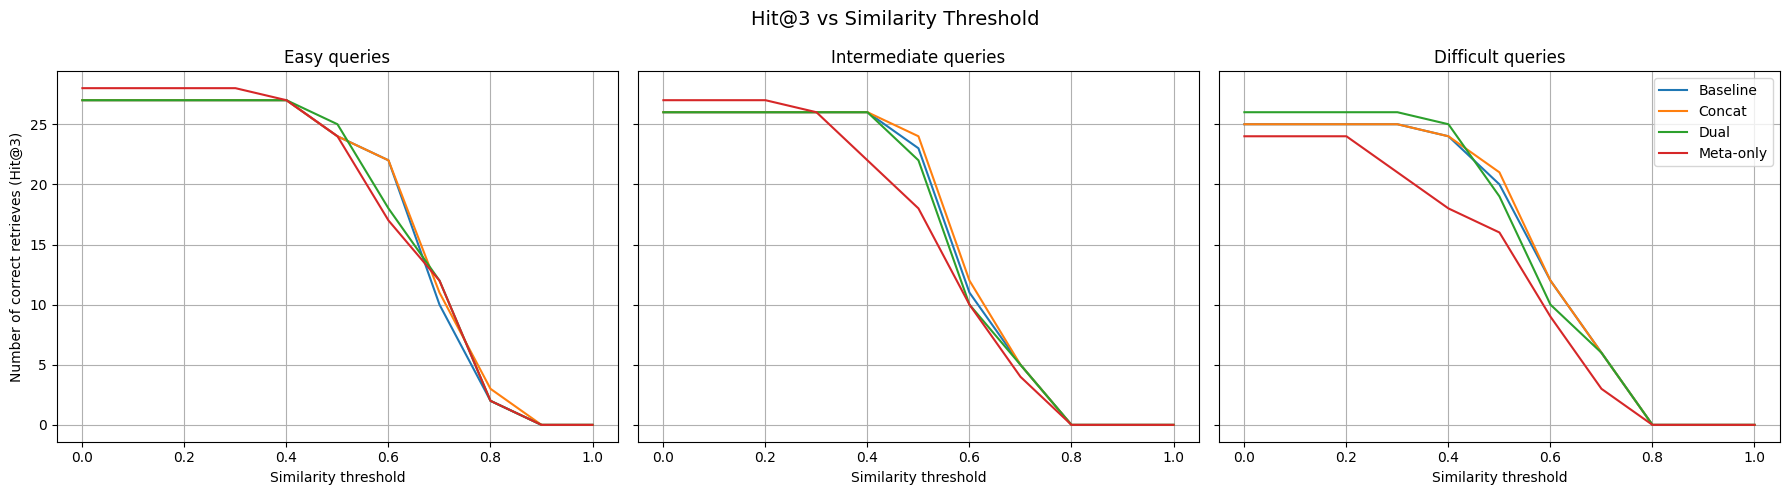

In [16]:
hits_by_retriever_easy = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

hits_by_retriever_intermediate = hit_at_k_vs_threshold(
    retrieval_intermediate,
    queries_intermediate,
    thresholds,
    k=3)

hits_by_retriever_difficult = hit_at_k_vs_threshold(
    retrieval_difficult,
    queries_difficult,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plots = [
    ("Easy queries", hits_by_retriever_easy),
    ("Intermediate queries", hits_by_retriever_intermediate),
    ("Difficult queries", hits_by_retriever_difficult),
]

for ax, (title, hits_dict) in zip(axes, plots):
    for name, hits in hits_dict.items():
        ax.plot(thresholds, hits, label=name)

    ax.set_title(title)
    ax.set_xlabel("Similarity threshold")
    ax.grid(True)

axes[0].set_ylabel("Number of correct retrieves (Hit@3)")

# Llegendària comuna
axes[-1].legend(loc="best")

plt.suptitle("Hit@3 vs Similarity Threshold", fontsize=14)
plt.tight_layout()
plt.show()